In [1]:
import numpy as np
from matplotlib import pyplot as plt, cm
from mpl_toolkits.mplot3d import Axes3D

domain = 1
nx = 257
ny = 257
dx = domain / (nx - 1)
dy = domain / (ny - 1)

x = np.linspace(0, domain, nx)
y = np.linspace(0, domain, ny)

c = 1
rho = 1
nu = 0.001 # kinematic viscosity (m2/s)
mu = nu * rho

# initial conditions
u = np.zeros((nx, ny))
v = np.zeros((nx, ny))
p = np.zeros((nx, ny))

# boundary conditions
# 1- u = 1 at y = 1 (lid)
u[:, -1] = c

# 2- u, v = 0 on the other boundaries
u[0, :] = v[0, :] = 0 # at x = 0
u[:, 0] = v[:, 0] = 0 # at y = 0
u[-1, :] = v[-1, :] = 0 # at x = 1

# 3- dp/dy = 0 at y = 0
p[:, 0] = p[:, 1]

# 4- p = 0 at y = 1
p[:, -1] = 0

# 5- dp/dx = 0 at x = 0, 2
p[0, :] = p[1, :]   # at x=0
p[-1, :] = p[-2, :] # at x=1


# reynold's number
def Re(c, domain, nu):
    print("Reynold's number =", c*domain/nu)

Re(c, domain, nu)

Reynold's number = 1000.0


In [2]:
"""
implementing chorin's projection method + central differences for spatial derivatives
steps:

1- predict: u_tentative using advection, diffusion and forces (if present)
2- solve poisson: solve PPE for scalar pressure field
3- correct: compute div free u(n+1) = un_tentative - (dt/rho) * grad(p(n+1))

i'll also exercise implementing functions for centraldiff and five-point stencil for laplace for first time
"""

"\nimplementing chorin's projection method + central differences for spatial derivatives\nsteps:\n\n1- predict: u_tentative using advection, diffusion and forces (if present)\n2- solve poisson: solve PPE for scalar pressure field\n3- correct: compute div free u(n+1) = un_tentative - (dt/rho) * grad(p(n+1))\n\ni'll also exercise implementing functions for centraldiff and five-point stencil for laplace for first time\n"

In [3]:
def cd_x(f): # central difference in x direction
    
    temp = np.zeros_like(f)

    temp[1:-1, 1:-1] = (f[2:, 1:-1] - f[0:-2, 1:-1])/(2*dx)

    return temp

def cd_y(f): # central difference in y direction

    temp = np.zeros_like(f)

    temp[1:-1, 1:-1] = (f[1:-1, 2:] - f[1:-1, 0:-2])/(2*dy)

    return temp

def laplace(f): # five-point stencil approximation

    temp = np.zeros_like(f)

    temp[1:-1, 1:-1] = (1/(dx**2)) * (f[2:, 1:-1] + f[:-2, 1:-1] + f[1:-1, 2:] + f[1:-1, :-2] - 4 * f[1:-1, 1:-1])

    return temp

In [4]:
# predictor equations

def predict(un, vn):

    d_un_dx = cd_x(un)
    d_un_dy = cd_y(un)

    laplace_un = laplace(un)
    laplace_vn = laplace(vn)

    # x-direction equation
    utent = (un + dt * ((- un*d_un_dx - vn*d_un_dy) + (nu*laplace_un)))

    d_vn_dx = cd_x(vn)
    d_vn_dy = cd_y(vn)
    
    # y-direction equation
    vtent = (vn + dt * ((- un*d_vn_dx - vn*d_vn_dy) + (nu*laplace_vn)))
    
    # boundary conditions
    utent[0, :] = 0; vtent[0, :] = 0    # at x = 0
    utent[-1, :] = 0; vtent[-1, :] = 0  # at x = 1
    utent[:, -1] = c; vtent[:, -1] = 0  # at y = 1
    utent[:, 0] = 0                     # at y = 0
    vtent[:, 0] = 0                     # at y = 0
    
    return utent, vtent

In [5]:
# solve poisson equation for pressure field

def ppe(p, utent, vtent, max_iterations=2000, tolerance=1e-4):

    rhs = ((dx**2))*(rho/dt)*(cd_x(utent) + cd_y(vtent))

    for it in range(max_iterations):
        pn = p.copy()
    
        p[1:-1, 1:-1] = (-1/4) * (rhs[1:-1, 1:-1]-
                        (pn[2:, 1:-1] + pn[:-2, 1:-1] + pn[1:-1, 2:] + pn[1:-1, :-2]))
        
        # boundary conditions
        p[:, 0] = p[:, 1]   # dp/dy = 0 at y = 0
        p[:, -1] = 0        # p = 0 at y = 1
        p[0, :] = p[1, :]   # dp/dx = 0 at x = 0
        p[-1, :] = p[-2, :] # dp/dx = 0 at x = 1

        # calculate L2 norm of the change
        residual = np.sqrt(np.sum((p - pn) ** 2)) / (nx * ny)
        
        if residual < tolerance:
            # then system has converged successfully
            break

    return p

In [6]:
# correct velocity field

def correct(utent, vtent, p):

    u = utent - (dt/rho) * cd_x(p)
    v = vtent - (dt/rho) * cd_y(p)

    # boundary conditions
    u[0, :] = 0; v[0, :] = 0   # at x = 0
    u[-1, :] = 0; v[-1, :] = 0 # at x = 1
    u[:, 0] = 0; v[:, 0] = 0   # at y = 0   added missing bottom wall BC
    u[:, -1] = c; v[:, -1] = 0 # at y = 1   enforced last

    return u, v

In [7]:
# implement chorin's projection method + fully explicit + CD in space

def chorinprojection(p, u, v, max_nt, conv_tol=1e-6):
    
    for n in range(max_nt):
        
        u_old = u.copy()
        v_old = v.copy()

        utent, vtent = predict(u, v)

        p = ppe(p, utent, vtent, max_iterations=2000, tolerance=1e-4)

        u, v = correct(utent, vtent, p)
        
        # calculating the maximum absolute difference
        u_diff = np.max(np.abs(u - u_old))
        v_diff = np.max(np.abs(v - v_old))
        
        # checking for steady state convergence
        if u_diff < conv_tol and v_diff < conv_tol:
            print(f"steady state reached at iteration {n}")
            print(f"Physical Time Simulated = {n * dt:.4f} seconds")
            print(f"Final Residuals: u_diff = {u_diff:.2e}, v_diff = {v_diff:.2e}")
            break
    else:
        # This triggers only if the loop finishes max_nt without breaking
        print(f"Warning: Reached max iterations ({max_nt}) without hitting tolerance {conv_tol}.")
        print(f"Current Residuals: u_diff = {u_diff:.2e}, v_diff = {v_diff:.2e}")
        print("You may need to increase max_nt or check for numerical instability.")

    return p, u, v

In [8]:
def timefunc():
    
    # 1- Convective Limit
    dt_conv = dx / (np.max(np.abs(u)) + 1e-10)

    # 1- Diffusive Limit
    dt_diffusive = (1/4) * (dx**2) / nu

    dt_critical = min(dt_diffusive, dt_conv)

    # as long as our dt < dt_critical, our backward scheme is safe
    # otherwise, we'll have to use true upwind scheme
    print("nt =", nt)
    print("dt =", dt)
    print("Critical time step for stability =", dt_critical)

In [9]:
# setup for Re = 1000

nt = 50000
max_nt = nt

nu = 0.001 # kinematic viscosity (m2/s)
dt = 0.001

In [10]:
Re(c, domain, nu)
timefunc()

Reynold's number = 1000.0
nt = 50000
dt = 0.001
Critical time step for stability = 0.003814697265625


In [11]:
p, u, v = chorinprojection(p, u, v, max_nt, conv_tol=1e-6)

steady state reached at iteration 35244
Physical Time Simulated = 35.2440 seconds
Final Residuals: u_diff = 9.68e-07, v_diff = 1.00e-06


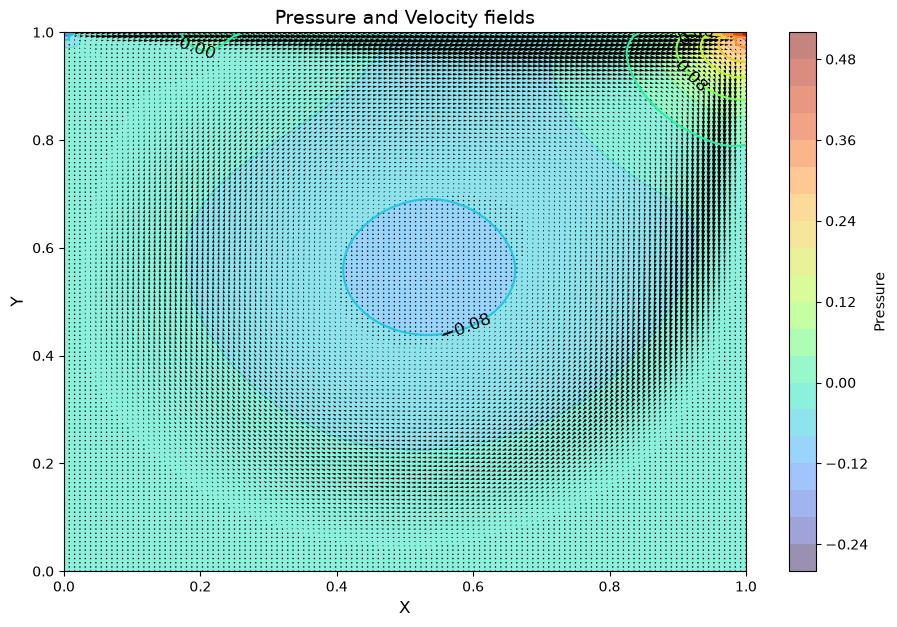

In [12]:
# Create the meshgrid variables needed for this plot
X, Y = np.meshgrid(x, y)

# Create figure and set dpi and figure size
fig = plt.figure(figsize=(11,7), dpi=100)

# Contourf plot for pressure field with colorbar
cf = plt.contourf(X, Y, p.T, alpha=0.5, cmap='turbo', levels=20)
plt.colorbar(cf, label='Pressure')

# Contour plot for pressure field outlines
contour = plt.contour(X, Y, p.T, cmap='turbo', levels=10)
plt.clabel(contour, inline=False, fontsize=12, colors = 'black')

# Quiver plot for velocity field
quiv = plt.quiver(X[::2, ::2], Y[::2, ::2], u.T[::2, ::2], v.T[::2, ::2]) 

# Setting labels for the x and y axes
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)

# Setting the title for the plot
plt.title('Pressure and Velocity fields', fontsize=14)

# Display the plot
plt.show()

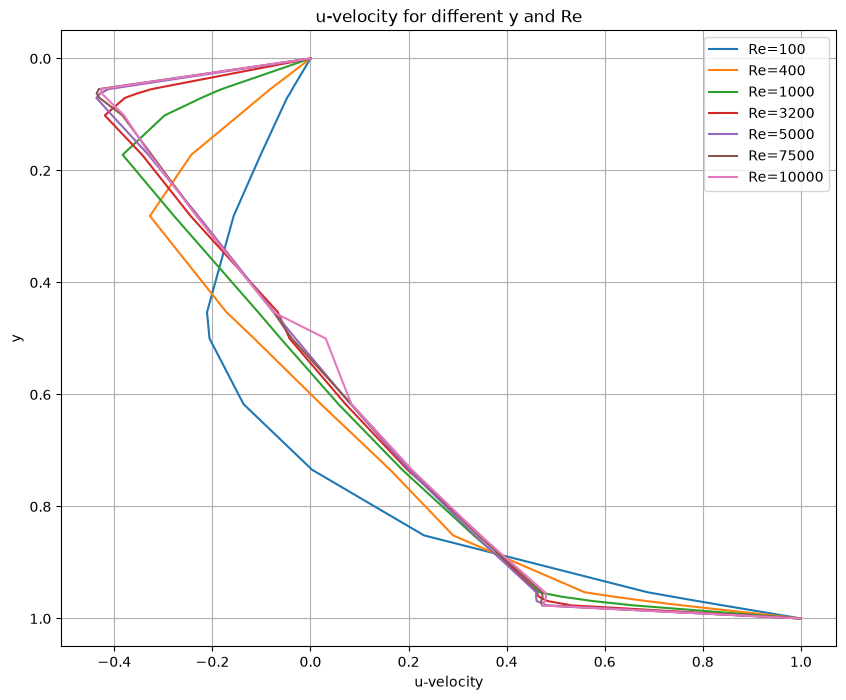

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# reading the txt file
with open('Ghia-1982.txt', 'r') as file:
    lines = file.readlines()

# adjusting the lines range to match your data
lines = lines[1:]  # Adjust these numbers

# processing lines to obtain data
data = [list(map(float, line.split())) for line in lines]

# creating DataFrame from data
df = pd.DataFrame(data, columns=['y', 'Re=100', 'Re=400', 'Re=1000', 'Re=3200', 'Re=5000', 'Re=7500', 'Re=10000'])

# setting y as index
df.set_index('y', inplace=True)

# plotting
plt.figure(figsize=(10,8))
for column in df.columns:
    plt.plot(df[column].values, df.index.values, label=column) # use .values to get numpy arrays

plt.xlabel('u-velocity')
plt.ylabel('y')
plt.title('u-velocity for different y and Re')
plt.legend()
plt.gca().invert_yaxis()  # To invert y-axis
plt.grid(True)
plt.show()

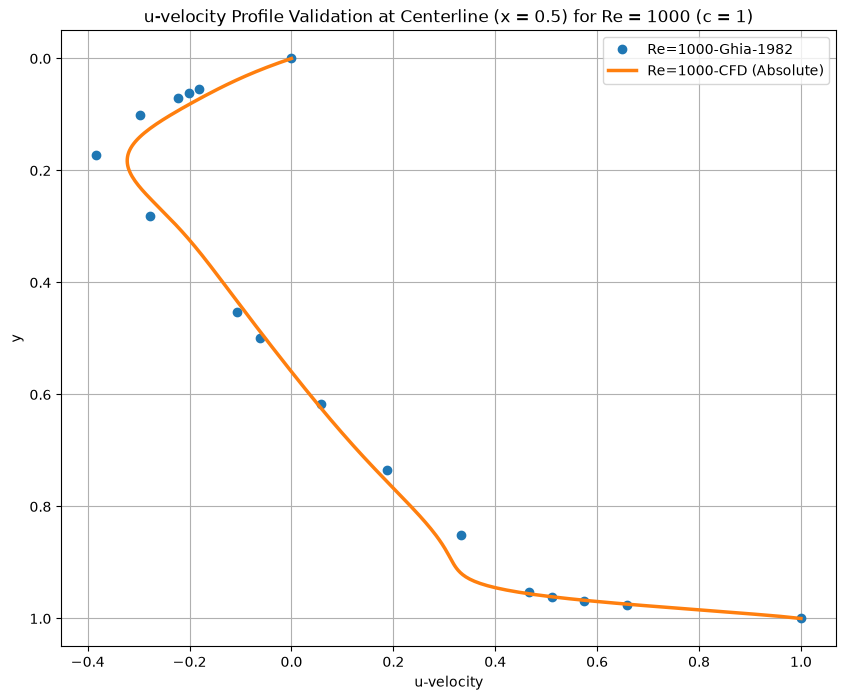

In [14]:
# validation plot for absolute u variation in y at x = 0.5 (at Re = 1000, v = 0.001)

plt.figure(figsize=(10, 8))

ghia_absolute_u = df['Re=1000'].values

# plotting the Ghia's comparison dots for Re=1000
plt.plot(ghia_absolute_u, df.index.values, 'o', label=f'Re=1000-Ghia-1982')

# extracting vertical centerline slice
u_centerline = u[int(nx / 2), :]

# plotting the raw, absolute code results as a continuous comparison line
plt.plot(u_centerline, y, '-', label='Re=1000-CFD (Absolute)', linewidth=2.5) 

plt.xlabel('u-velocity')
plt.ylabel('y')
plt.title(f'u-velocity Profile Validation at Centerline (x = 0.5) for Re = 1000 (c = {c})')
plt.legend()
plt.gca().invert_yaxis()  # keeping inversion mapping intact
plt.grid(True)
plt.show()